In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

dados = {
    'ID_Aluno': range(1,101),
    'Serie': np.random.choice(['1A','2A','3A'],100),
    'Tempo_Uso_Horas': np.random.randint(1,8,100),
    'Tentativas_Login': np.random.randint(1,10,100),
    'Sites_Acessados': np.random.randint(5,40,100),
    'Ocorrencias': np.random.randint(0,4,100)
}

df = pd.DataFrame(dados)

df['Status'] = np.where(
    (df['Tentativas_Login'] > 6) &
    (df['Ocorrencias'] > 1),
    'Suspeito',
    'Normal'
)

df.head()

,ID_Aluno,Serie,Tempo_Uso_Horas,Tentativas_Login,Sites_Acessados,Ocorrencias,Status
0,1,3A,4,9,39,0,Normal
1,2,1A,7,3,29,3,Normal
2,3,3A,3,7,39,3,Suspeito
3,4,3A,3,6,29,1,Normal
4,5,1A,1,8,33,2,Suspeito


In [2]:
df.loc[5,'Serie'] = ''
df.loc[15,'Tempo_Uso_Horas'] = np.nan

df.loc[20,'Serie'] = 'XYZ'
df.loc[30,'Status'] = 'Erro'

df.loc[40,'Tempo_Uso_Horas'] = 50
df.loc[50,'Tentativas_Login'] = 100

df.loc[60] = df.loc[59]

df


,ID_Aluno,Serie,Tempo_Uso_Horas,Tentativas_Login,Sites_Acessados,Ocorrencias,Status
0,1,3A,4.0,9,39,0,Normal
1,2,1A,7.0,3,29,3,Normal
2,3,3A,3.0,7,39,3,Suspeito
3,4,3A,3.0,6,29,1,Normal
4,5,1A,1.0,8,33,2,Suspeito
...,...,...,...,...,...,...,...
95,96,1A,1.0,8,37,3,Suspeito
96,97,1A,3.0,4,12,2,Normal
97,98,3A,6.0,6,9,1,Normal
98,99,1A,1.0,8,8,1,Normal


In [3]:
df.to_csv('controle_notebooks.csv', index=False)

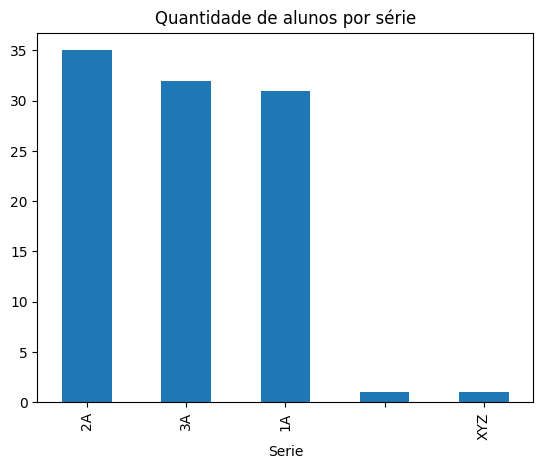

In [4]:
import matplotlib.pyplot as plt

df['Serie'].value_counts().plot(kind='bar')

plt.title('Quantidade de alunos por série')
plt.show()

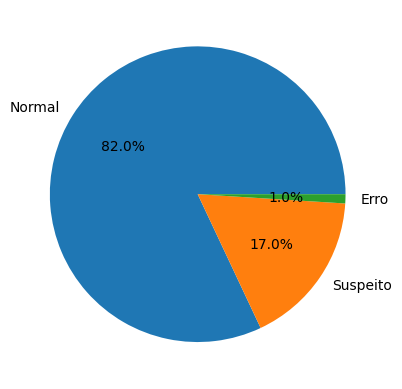

In [5]:
df['Status'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.show()


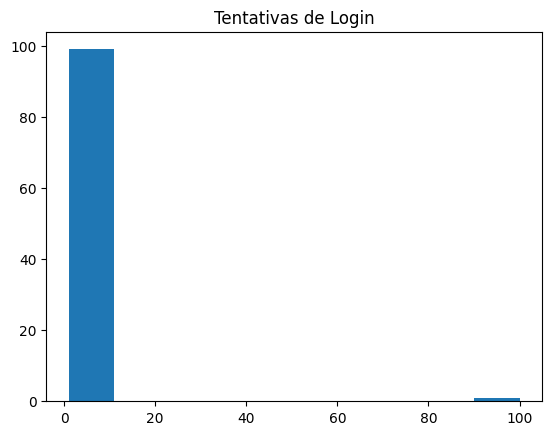

In [6]:
plt.hist(df['Tentativas_Login'])

plt.title('Tentativas de Login')
plt.show()

In [7]:
df.replace('', np.nan, inplace=True)

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

df = df[df['Serie'].isin(['1A','2A','3A'])]

df = df[df['Status'].isin(['Normal','Suspeito'])]

df = df[df['Tempo_Uso_Horas'] < 20]

df = df[df['Tentativas_Login'] < 20]

df.head()

,ID_Aluno,Serie,Tempo_Uso_Horas,Tentativas_Login,Sites_Acessados,Ocorrencias,Status
0,1,3A,4.0,9,39,0,Normal
1,2,1A,7.0,3,29,3,Normal
2,3,3A,3.0,7,39,3,Suspeito
3,4,3A,3.0,6,29,1,Normal
4,5,1A,1.0,8,33,2,Suspeito


In [8]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Serie'] = le.fit_transform(df['Serie'])

df['Status'] = le.fit_transform(df['Status'])

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('Status', axis=1)

y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.svm import SVC

modelo = SVC()

modelo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [11]:
predicao = modelo.predict(X_test)

predicao[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [13]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_test, predicao)

print("Acurácia:", acuracia)

Acurácia: 0.7368421052631579
